# Car Price Prediction using Linear Regression

Objective:
Build a machine learning model that predicts car selling price using
multiple features like year, km driven, fuel type, transmission, owner type etc.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv('cardekho.csv')
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

 Data Cleaning

In [3]:
data = data.drop_duplicates()
data = data.dropna()

In [4]:
data = data[data["selling_price"] < 5000000]    # removing extreme outliers
data = data[data["km_driven"] < 500000]         # removing extreme outliers 

Selecting dependent and independent variables

In [5]:
print(data.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')


In [6]:
X = data[["year", "km_driven", "fuel", "seller_type", "transmission", "owner"]]
y = data["selling_price"]

In [7]:
X = pd.get_dummies(X, drop_first=True)    #Converting text columns to numeric

Train Test Split

In [8]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split( X , y , test_size = 0.2, random_state = 1 )

Building and Training MLR Model

In [9]:
from sklearn.linear_model import LinearRegression
a = LinearRegression()
a.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
print("Intercept:", a.intercept_)
print("Coefficients:", a.coef_)

Intercept: -64127228.648727275
Coefficients: [ 3.24158633e+04 -9.90618438e-01  2.64270121e+05 -4.79714927e+05
  2.92828272e+04  4.80541317e+02 -2.82418172e+04  1.48520096e+05
 -7.47368917e+05 -2.27436392e+04 -4.78599156e+04  2.19500904e+05
 -4.61439497e+04]


In [11]:
y_pred = a.predict(x_test)
y_pred = pd.DataFrame(y_pred, columns=['Predicted Values'])

To find errors in predictions

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.45326172207699367
MAE: 197658.3643058742
MSE: 106318267650.08904


# Visualizations

Actual vs Predicted Prices

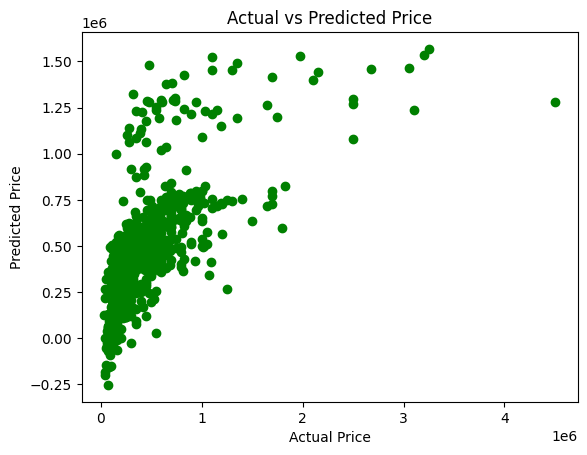

In [13]:
plt.scatter(y_test , y_pred , color='g' , marker='o')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

Residual Plot

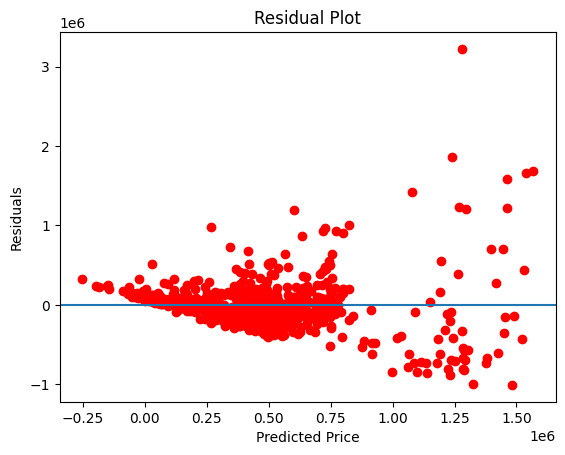

In [14]:
# making predictions again
y_pred = a.predict(x_test)

# converting both to 1-D arrays

y_pred = np.array(y_pred).ravel()
y_test_array = np.array(y_test).ravel()

# computing residuals AFTER fixing shapes
residuals = y_test_array - y_pred

# plotting

plt.scatter(y_pred, residuals, c='r', marker='o')
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Predict a New Car Price

In [19]:
sample = pd.DataFrame({
    "year":[2025],
    "km_driven":[2000],
    "fuel":["Diesel"],
    "seller_type":["Individual"],
    "transmission":["Manual"],
    "owner":["First Owner"]
})

sample = pd.get_dummies(sample)
sample = sample.reindex(columns=X.columns, fill_value=0)

predicted_price = a.predict(sample)
print(predicted_price)

[1001572.73929928]
